C:\Users\Areesha Khan\AppData\Local\Temp\ipykernel_3832\3533115141.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='City', y='Average',
C:\Users\Areesha Khan\AppData\Local\Temp\ipykernel_3832\3533115141.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Grade',
C:\Users\Areesha Khan\AppData\Local\Temp\ipykernel_3832\3533115141.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_avg, x='City', y='Average',


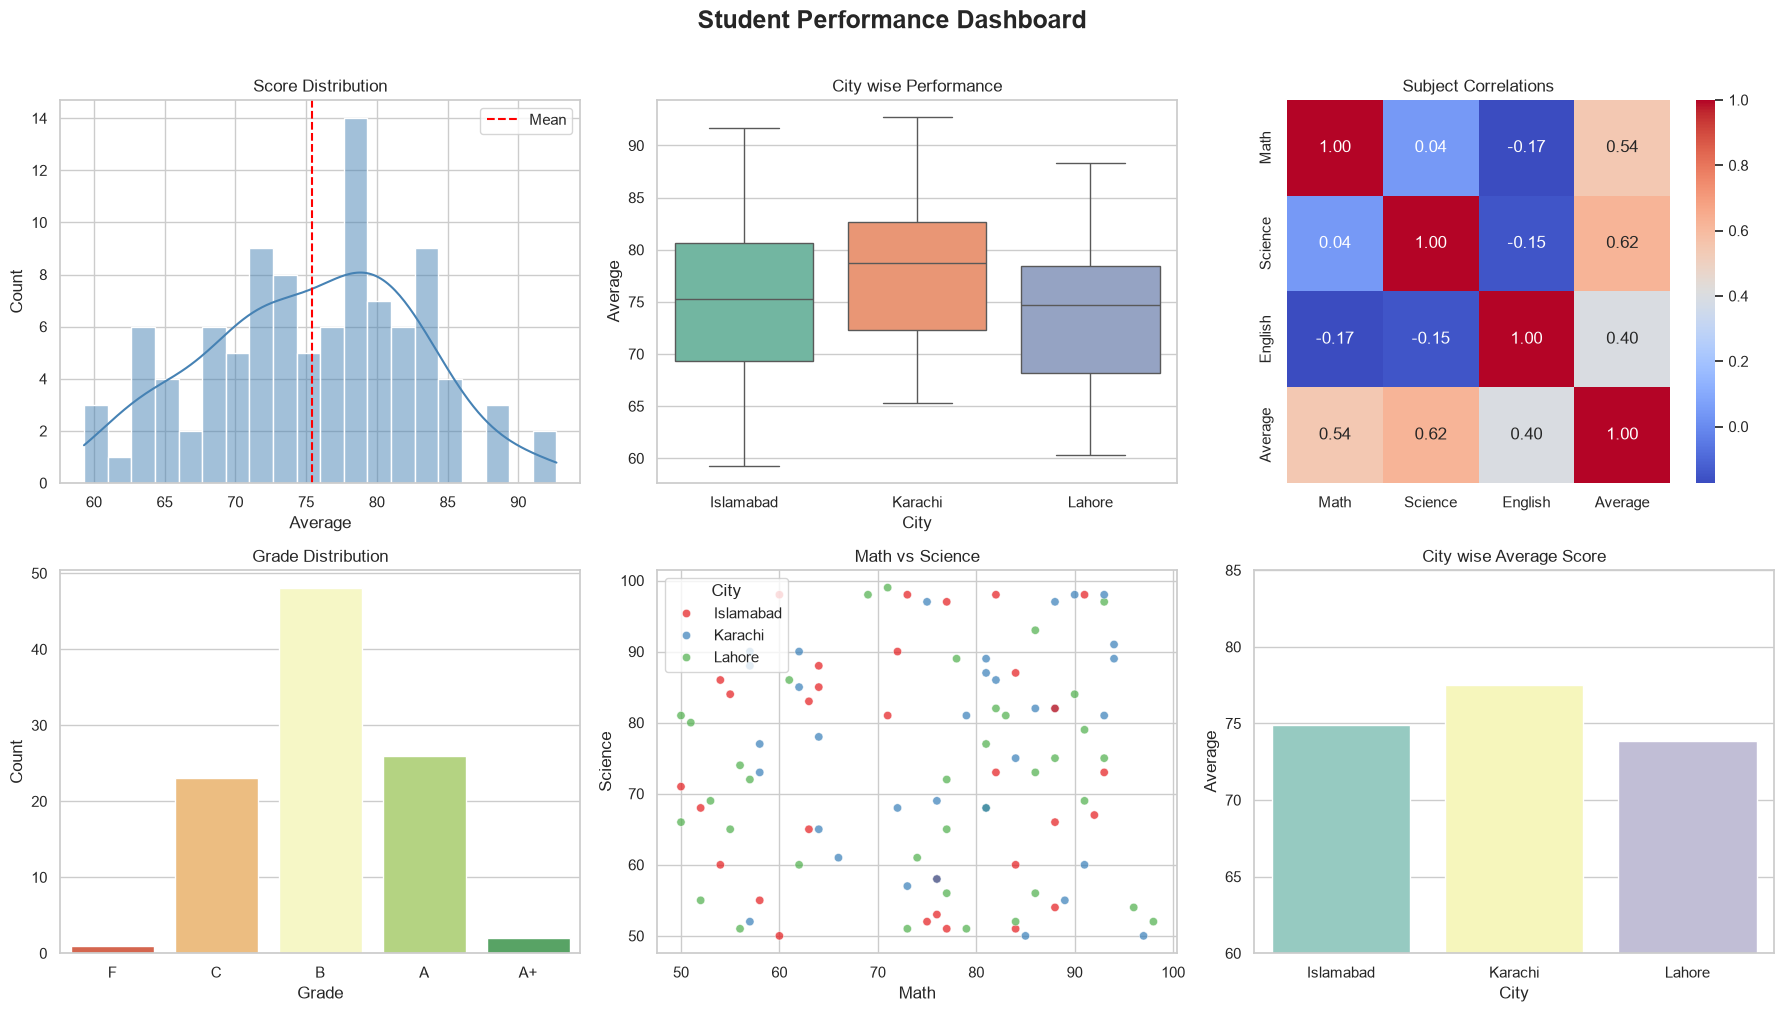

Dashboard saved as dashboard.png ✅


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================
# STUDENT PERFORMANCE DASHBOARD
# ============================================

np.random.seed(42)
sns.set_theme(style='whitegrid')

data = {
    
    'City':    np.random.choice(
                   ['Karachi','Lahore','Islamabad'], 100),
    'Math':    np.random.randint(50, 100, 100),
    'Science': np.random.randint(50, 100, 100),
    'English': np.random.randint(50, 100, 100),
}
df = pd.DataFrame(data)
df['Average'] = df[['Math','Science','English']].mean(axis=1).round(1)
df['Grade'] = pd.cut(
    df['Average'],
    bins=[0, 60, 70, 80, 90, 100],
    labels=['F', 'C', 'B', 'A', 'A+']
)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Student Performance Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# Plot 1 — Average distribution
sns.histplot(data=df, x='Average', bins=20,
             color='steelblue', ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Score Distribution')
axes[0, 0].axvline(df['Average'].mean(), color='red',
                    linestyle='--', label='Mean')
axes[0, 0].legend()

# Plot 2 — City wise boxplot
sns.boxplot(data=df, x='City', y='Average',
            palette='Set2', ax=axes[0, 1])
axes[0, 1].set_title('City wise Performance')

# Plot 3 — Correlation heatmap
corr = df[['Math','Science','English','Average']].corr()
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[0, 2], square=True)
axes[0, 2].set_title('Subject Correlations')

# Plot 4 — Grade countplot
sns.countplot(data=df, x='Grade',
              palette='RdYlGn', ax=axes[1, 0])
axes[1, 0].set_title('Grade Distribution')
axes[1, 0].set_xlabel('Grade')
axes[1, 0].set_ylabel('Count')

# Plot 5 — Scatter Math vs Science
sns.scatterplot(data=df, x='Math', y='Science',
                hue='City', palette='Set1',
                alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Math vs Science')

# Plot 6 — City wise average bar
city_avg = df.groupby('City')['Average'].mean().reset_index()
sns.barplot(data=city_avg, x='City', y='Average',
            palette='Set3', ax=axes[1, 2])
axes[1, 2].set_title('City wise Average Score')
axes[1, 2].set_ylim(60, 85)

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as dashboard.png ✅")